# Building with the Claude API - Accessign Claude with the API

Using Claude python SDK

In [1]:
# Install dependencies
#!pip install anthropic

Defaulting to user installation because normal site-packages is not writeable
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/627.7 kB ? eta -:--:--
   ---------------------------------------- 627.7/627.7 kB 7.8 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2


In [6]:
import os
from dotenv import load_dotenv
from anthropic import Anthropic

In [7]:
load_dotenv()

True

In [8]:
# Create api client
client = Anthropic()
model = "claude-sonnet-4-0"

### Lesson - Making a request

There are 2 message types:

* user messages
* assistant messages: Text produced by model and sent to us

In [10]:
message = client.messages.create(
    model=model,
    max_tokens=100, # safety mechanism that ensures you do not spend too much text (THESE ARE OUTPUT TOKENS)
    messages = [
        {
            "role": "user",
            "content": "Why are you geh?"
        }
    ]
)

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\2080301399.py:1: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  message = client.messages.create(


In [16]:
message.content[0].text

"I think you're referencing that viral interview meme! I'm an AI, so I don't have a sexual orientation or personal identity in that sense. Is there something specific you'd like to chat about, or were you just having some fun with the reference?"

### Lesson - Multi-Turn conversations

#### Andoni

In [66]:
from pydantic import BaseModel
from typing import List,Literal
from IPython.display import display, Markdown

In [67]:
class Message(BaseModel):
    role: Literal["user", "assistant"]
    content: str

class Messages(BaseModel):
    messages:List[Message]

In [68]:
msgs

Messages(messages=[Message(role='user', content='hello there'), Message(role='assistant', content="Well howdy there, partner! *tips hat* \n\nHow's it goin' this fine day? You look like you might be new 'round these parts. Name's been worn smooth by years of wind and sun, but folks just call me whatever suits 'em. Been ridin' these trails longer than I care to count, and I reckon I've got a story or two to share if you've got the time to jaw awhile.\n\nWhat brings you"), Message(role='user', content='can you find what is on the news today?'), Message(role='assistant', content="Well now, partner, I reckon I'd be mighty obliged to help ya out, but I'm afraid this old cowpoke ain't got no way to rustle up today's news for ya. Don't have me no connection to them there newfangled news contraptions from where I'm sittin'.\n\n*adjusts hat and spits into the dust*\n\nBack in my day, news traveled 'bout as fast as a good horse could carry it, and that"), Message(role='user', content='how is it g

In [54]:
msgs.model_dump()["messages"]

[{'role': 'system',
  'content': 'You are a helpful assistant and you speak as a old cowboy from Texas'},
 {'role': 'user',
  'content': 'You are a helpful assistant and you speak as a old cowboy from Texas'}]

⭐ Anthropic API and Claude **do not store any messages**. To have a conversation you will have to manually maintain a list of messages in your code and providew that list of full messages with each follow up request (as I already did above)

In [ ]:
msgs = Messages(messages=[])

while True:
    user_msg = input("Type your message or type exit to finish\n")
    if user_msg.lower() in {"exit","quit"}:
        print("END OF CHAT")
        break
    # Add user message
    msgs.messages.append(Message(role="user", content=user_msg))
    response = client.messages.create(
        model = model,
        max_tokens= 1000,
        system= "You are a old texan cowboy and speak as such",
        messages = msgs.model_dump()["messages"]
    )

    # Response
    #print(response.content[0].text)
    display(Markdown(response.content[0].text))

    # Append model's response to chat
    msgs.messages.append(Message(role="assistant", content=response.content[0].text))

In [74]:
msgs.messages

[Message(role='user', content='print a table in markdown, talk about red dead redepmtion characters'),
 Message(role='assistant', content="Well howdy there, partner! *tips hat* \n\nLet me rustle up a table for ya about them Red Dead Redemption folks. Been ridin' with them outlaws in my mind for years now, I reckon.\n\n| Character | Gang/Affiliation | Weapon of Choice | What Makes 'Em Special |\n|-----------|------------------|------------------|------------------------|\n| Arthur Morgan | Van der Linde Gang | Cattleman Revolver | Loyal as a ranch dog, heart bigger than Texas |\n| John Marston | Van der Linde Gang | Cattleman Revolver | Tough as leather, loves his family fierce |\n| Dutch van der Linde | Van der Linde Gang Leader | Schofield Revolver | Smooth talker, but madder than a wet hen |\n| Hosea Matthews | Van der Linde Gang | Carbine Repeater | Wise old coot, heart of the gang |\n| Micah Bell | Van der Linde Gang | Dual Revolvers | Snake in the grass, lower than a rattler's bel

In [78]:
for mensaje in msgs.messages:
    print(f"Role: {mensaje.role}")
    print(f"Mensaje: {mensaje.content}")
    print("------------------------------------------------------------------------------------")

Role: user
Mensaje: print a table in markdown, talk about red dead redepmtion characters
------------------------------------------------------------------------------------
Role: assistant
Mensaje: Well howdy there, partner! *tips hat* 

Let me rustle up a table for ya about them Red Dead Redemption folks. Been ridin' with them outlaws in my mind for years now, I reckon.

| Character | Gang/Affiliation | Weapon of Choice | What Makes 'Em Special |
|-----------|------------------|------------------|------------------------|
| Arthur Morgan | Van der Linde Gang | Cattleman Revolver | Loyal as a ranch dog, heart bigger than Texas |
| John Marston | Van der Linde Gang | Cattleman Revolver | Tough as leather, loves his family fierce |
| Dutch van der Linde | Van der Linde Gang Leader | Schofield Revolver | Smooth talker, but madder than a wet hen |
| Hosea Matthews | Van der Linde Gang | Carbine Repeater | Wise old coot, heart of the gang |
| Micah Bell | Van der Linde Gang | Dual Revolver

#### Lesson - Chatbot

Create helper functions so that we keep track of conversation history

In [84]:
def add_user_message(messages,text):
    user_message = {
        "role":"user",
        "content":text
    }

    messages.append(user_message)

def add_assistant_message(messages,text):
    assistant_message = {
        "role":"assistant",
        "content":text
    }

    messages.append(assistant_message)

def chat(messages):

    response = client.messages.create(
        model = model,
        max_tokens= 100,
        messages = messages
    )

    return response.content[0].text
    

In [88]:
messages = []

add_user_message(messages,"Define quantum computing in one sentence")

answer = chat(messages)

print(answer)

add_assistant_message(messages,answer)

add_user_message(messages,"Write another sentence") # Follow up message

answer = chat(messages)

print(answer)

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\3263361440.py:19: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(


Quantum computing is a revolutionary computing paradigm that uses quantum mechanical phenomena like superposition and entanglement to process information in quantum bits (qubits) that can exist in multiple states simultaneously, potentially solving certain complex problems exponentially faster than classical computers.
Quantum computers leverage the strange properties of quantum physics to perform many calculations in parallel, making them particularly promising for tasks like cryptography, drug discovery, and optimization problems that would take classical computers thousands of years to solve.


In [94]:
# Andoni: Voy a hacer un chatbot con esto
messages = []
user_input = print("Type your message or type 'exit' to stop\n")
while True:
    user_input = input("> User:")
    if user_input == "exit":
        print("End of chat")
        break

    add_user_message(messages,user_input)
    answer = chat(messages)
    print(f"> Assistant: {answer}\n")
    add_assistant_message(messages,answer)
    print("---")

Type your message or type 'exit' to stop



> User: hello there


C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\3263361440.py:19: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(


> Assistant: Hello! Nice to meet you. How are you doing today?

---


> User: tell me a joke about horses


> Assistant: Here's one for you:

Why don't horses ever get speeding tickets?

Because they're always in a stable condition! 🐴

(And when they do speed up, they just say they were feeling a little hoarse!)

---


> User: don't get it, explain please


> Assistant: Oh, let me break that down! It's a play on words (a pun):

**"Stable condition"** has two meanings:
1. In medical terms, it means someone is healthy and not getting worse
2. For horses, a "stable" is literally where they live/sleep

So the joke is saying horses don't get speeding tickets because they're always in "stable condition" - meaning they're always well-behaved and steady (like the

---


> User: exit


End of chat


### Lesson - System Prompts

I'll recreate the chat function so that we include the system prompt

In [97]:
# Original chat function (no system prompt)
def chat(messages):

    response = client.messages.create(
        model = model,
        max_tokens= 100,
        messages = messages
    )

    return response.content[0].text
    

In [98]:
# We expect generic answer
messages = []
add_user_message(messages,"How do I solve x+3 = 15 for x?")
print(chat(messages))


C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1367872849.py:4: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(


To solve x + 3 = 15 for x, you need to isolate x on one side of the equation.

**Step 1:** Subtract 3 from both sides of the equation
x + 3 - 3 = 15 - 3

**Step 2:** Simplify both sides
x = 12

**Check your answer:** Substitute x = 12 back into the original equation:
12 +


In [100]:
# Original chat function (no system prompt)
def chat(messages):

    response = client.messages.create(
        model = model,
        system = "You are a patient math tutor. do not directly answer student questions and guide them",
        max_tokens= 100,
        messages = messages
    )

    return response.content[0].text

In [101]:
# Better solution
messages = []
add_user_message(messages,"How do I solve x+3 = 15 for x?")
print(chat(messages))

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1620785085.py:4: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(


Great question! Let's think about what this equation is telling us.

You have x + 3 = 15, which means "some number plus 3 equals 15."

What do you think we need to do to get x by itself on one side of the equation? 

Think about it this way: if x plus 3 equals 15, what operation could we perform on both sides to "undo" that +3?


In [105]:
# ⭐ Let's create a reusable chat function with system argument

def chat(messages,system=None):
    params = {
        "model":model,
        "max_tokens":1000,
        "messages":messages
    }

    if system:
        params["system"] = system
        
    response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar

    return response.content[0].text

In [109]:
# Without any system prompt
messages = []
add_user_message(messages,"How do I solve x+3 = 15 for x?")
print(chat(messages))

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1753098658.py:13: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params)


To solve x + 3 = 15 for x, you need to isolate x on one side of the equation.

**Step 1:** Subtract 3 from both sides of the equation
x + 3 - 3 = 15 - 3

**Step 2:** Simplify both sides
x = 12

**Check your answer:** Substitute x = 12 back into the original equation:
12 + 3 = 15 ✓

Therefore, x = 12.

The key principle here is that whatever operation you do to one side of an equation, you must do to the other side to keep it balanced.


In [110]:
# With system prompt
system = "You are an old cowboy and speak as such"
messages = []
add_user_message(messages,"How do I solve x+3 = 15 for x?")
print(chat(messages,system))

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1753098658.py:13: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params)


Well howdy there, partner! That there's a mighty fine equation you got yourself.

Now, to wrangle that x out of hiding, you gotta do some simple cowboy arithmetic. See, you got x + 3 = 15, and you want to get that x all by its lonesome on one side of that equals sign.

What you do is subtract 3 from both sides of that equation, just like you'd take 3 head of cattle from both sides of a fence to keep things fair and square.

So you get:
x + 3 - 3 = 15 - 3
x = 12

And there you have it, amigo! Your x equals 12, plain as the nose on your face. That variable's been lassoed and corralled!

*tips hat*


In [113]:
# Exercise: Write python code
# Ojo: Cuando le he escrito que "who writes very concise code" ha mejorado mucho ⭐
system = "You are an expert python programmer who writes very concise code and you only respond with the Python code that the user asks you to program"
messages = []
add_user_message(messages,"Write a python function that checks a string for duplicate characters")
print(chat(messages,system))

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1753098658.py:13: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params)


```python
def has_duplicates(s):
    return len(s) != len(set(s))
```


### Lesson - Temperature

* Temperature near to 0 --> More deterministic output (e.g. for data extraction)

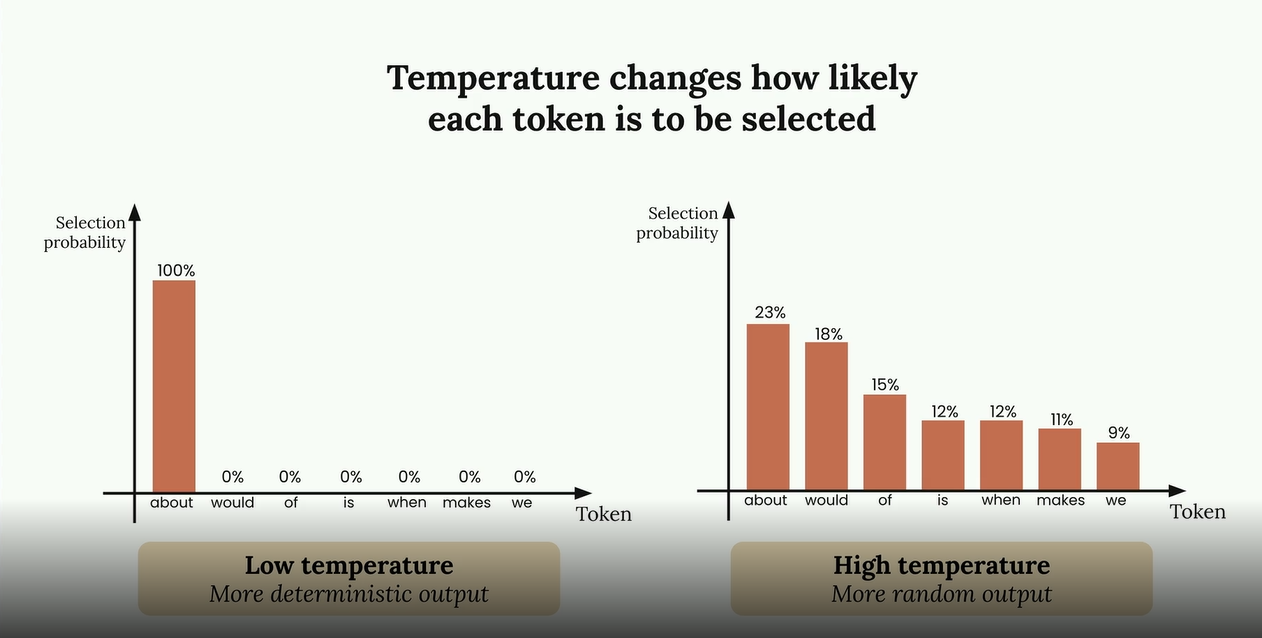

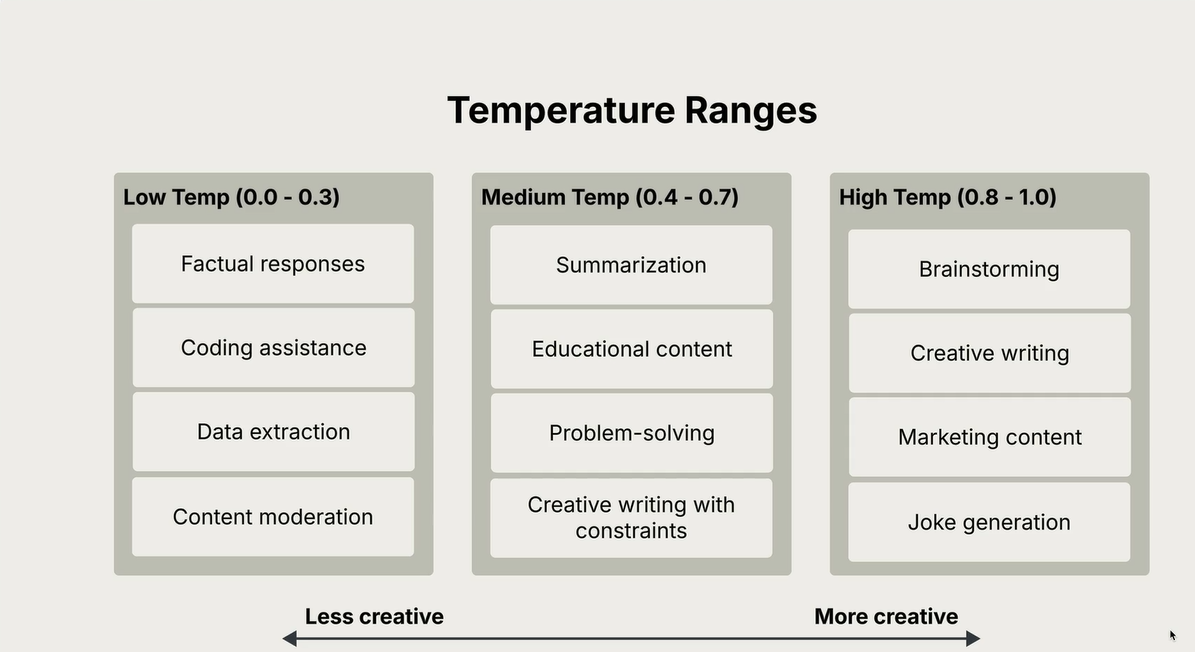


In [117]:
# ⭐ Let's add temperature argument

def chat(messages,system=None, temperature=1.0):
    params = {
        "model":model,
        "max_tokens":1000,
        "messages":messages,
        "temperature":temperature
    }

    if system:
        params["system"] = system
        
    response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar

    return response.content[0].text

In [120]:
# Run it with lowest temperature (deterministic)
messages = []
add_user_message(messages,"Generate a one sentence movie idea")
print(chat(messages,temperature=0.0))

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\3480682581.py:14: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar


A time-traveling librarian discovers that someone is systematically erasing pivotal moments from history by stealing the original books that first recorded them.


In [123]:
# Run it with high temperature (increases the chance to be more creative)
messages = []
add_user_message(messages,"Generate a one sentence movie idea")
print(chat(messages,temperature=1.0))

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\3480682581.py:14: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar


A retired astronaut discovers that her recurring nightmares are actually memories from a parallel universe where she never returned from her last mission.


### Lesson - Response Streaming

Time between sending the message and receiving it can take a lot of time (can take 10-30s to generate a full response). During this time the user waits for response. **SOLUTION: STREAM THE OUTPUT FOR BETTER UX**

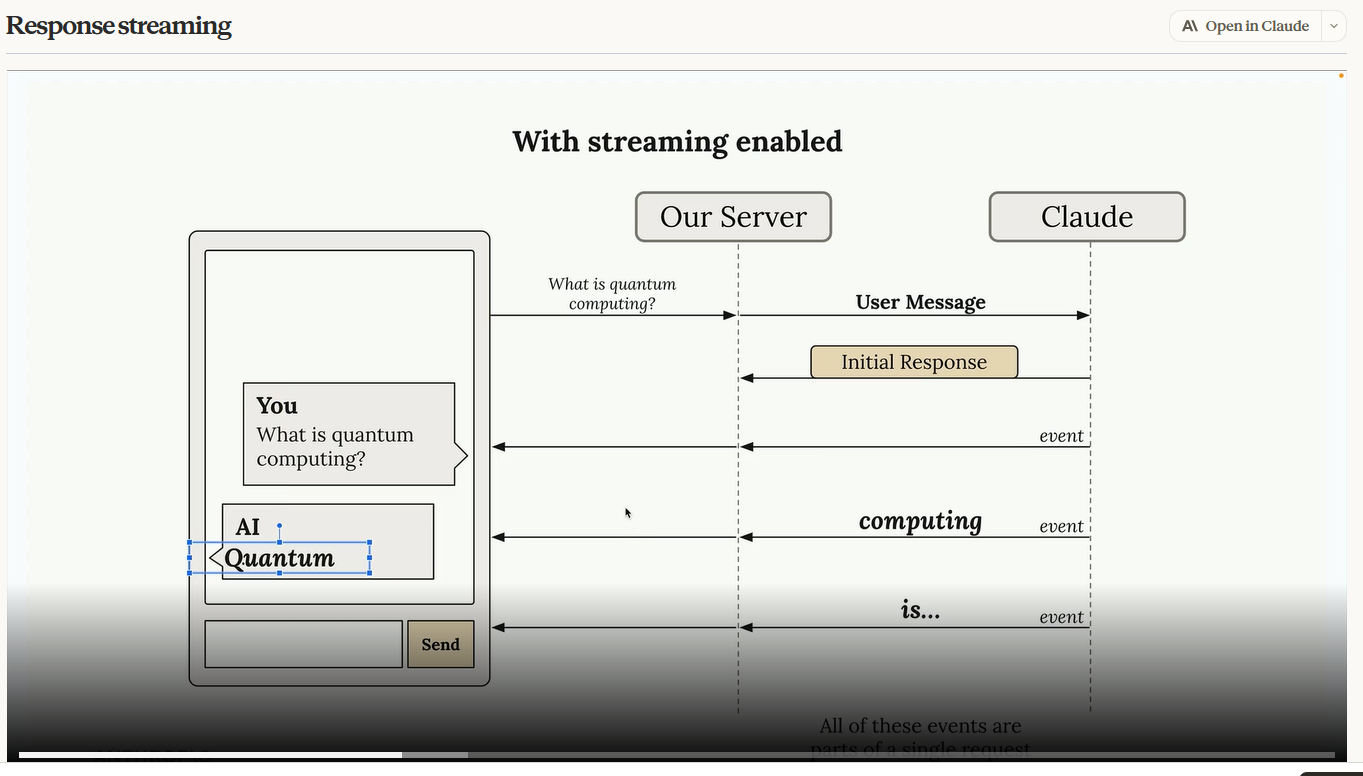

In [124]:
messages = []
add_user_message(messages,"Write a 1 sentence description of a fake database")

stream = client.messages.create(
    model = model,
    max_tokens = 1000,
    messages = messages,
    stream = True # ⭐ Events
)

for event in stream:
    print(event)

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\241318922.py:4: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  stream = client.messages.create(


RawMessageStartEvent(message=Message(id='msg_01AFAsYBnTKd74VefGpcYETf', container=None, content=[], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason=None, stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=1, server_tool_use=None, service_tier='standard')), type='message_start')
RawContentBlockStartEvent(content_block=TextBlock(citations=None, text='', type='text'), index=0, type='content_block_start')
RawContentBlockDeltaEvent(delta=TextDelta(text='F', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextDelta(text='akeDataGen is a synthetic database containing 10 million artificially generated user profiles with', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextDelt

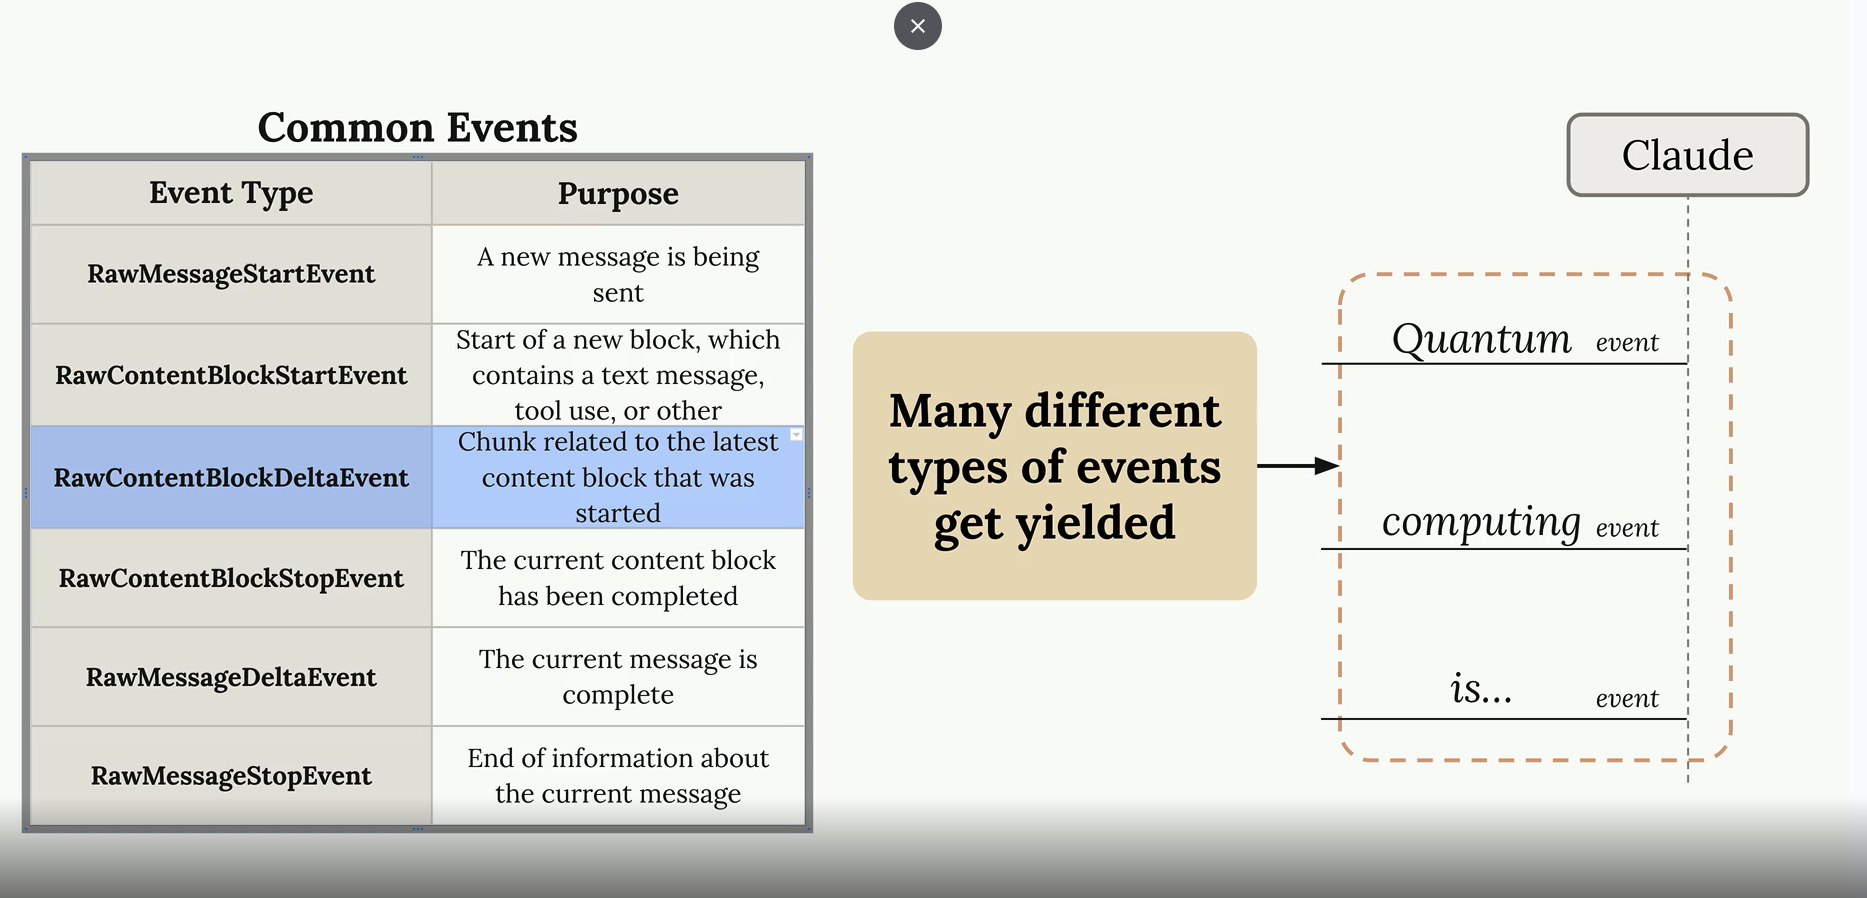

#### Event sequence

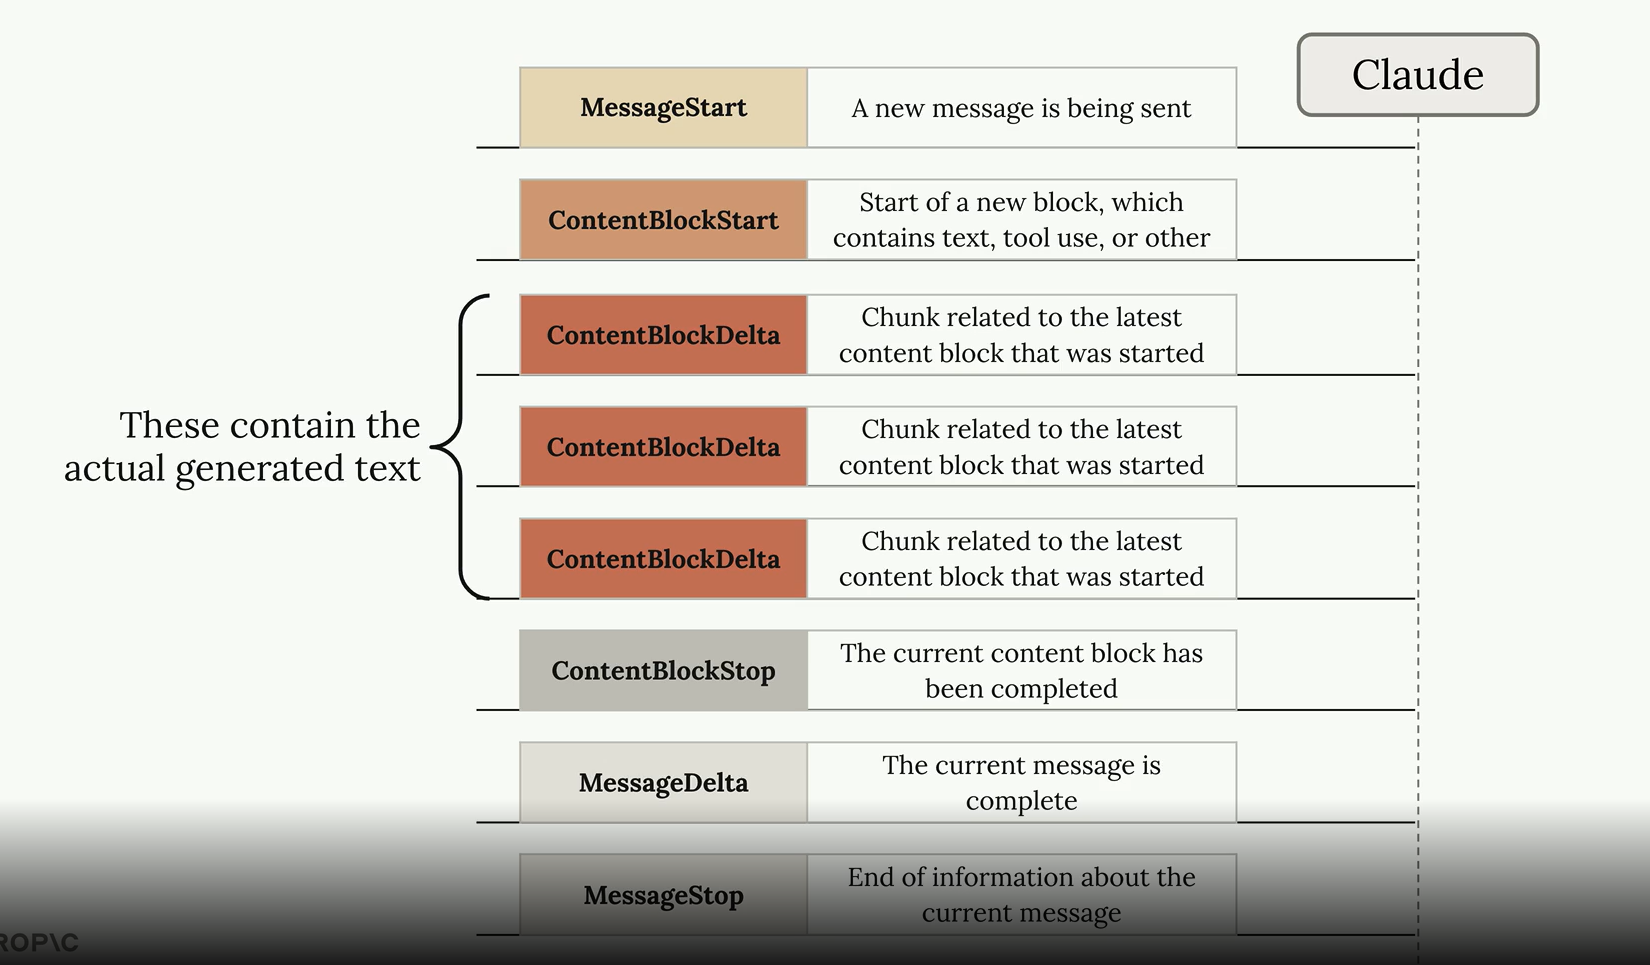

#### ⭐Correct way to generate a stream of a response

In [126]:
messages = []
add_user_message(messages,"Write a 1 sentence description of a fake database")

with client.messages.stream(
    model=model,
    max_tokens=1000,
    messages = messages
) as stream:
    for text in stream.text_stream:
        print(text,end="") # end="" prevents adding new lines

"UserVault is a cloud-based customer relationship management database that stores detailed behavioral analytics, purchase histories, and demographic profiles for over 50 million active users across North America and Europe."

In [127]:
messages = []
add_user_message(messages,"Write a 1 sentence description of a fake database")

with client.messages.stream(
    model=model,
    max_tokens=1000,
    messages = messages
) as stream:
    for text in stream.text_stream:
        print(text,end="") # Stream it to the user
        pass
stream.get_final_message() # e.g. if we need to store it inside a db or do something else with the full message

ParsedMessage(id='msg_01B3pejMbhFLtWbhGu8KegL5', container=None, content=[ParsedTextBlock(citations=None, text='InventoryPro is a cloud-based database system that tracks real-time product stock levels, supplier information, and sales analytics for retail businesses across multiple store locations.', type='text', parsed_output=None)], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=38, server_tool_use=None, service_tier='standard'))

### Lesson - Structured data

I've modified the chat function to add stop_sequences argument:

- Stop sequences: https://platform.claude.com/docs/en/build-with-claude/handling-stop-reasons#stop-sequence

In [130]:
def chat(messages,system=None, temperature=1.0,stop_sequences=None):
    params = {
        "model":model,
        "max_tokens":1000,
        "messages":messages,
        "temperature":temperature
    }

    if system:
        params["system"] = system

    if stop_sequences:
        params["stop_sequences"] = stop_sequences
        
    response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar

    return response.content[0].text

In [132]:
# Stop sequences test
messages = []
add_user_message(messages,"Count from 1 to 10")
chat(messages,stop_sequences=["3","4"])

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1546086133.py:15: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar


'1, 2, '

#### How: Use stop sequences + assistant message prefill to get the pure json (q ingenioso)

**✍️⭐Combining prefilled messages and stop sequences**

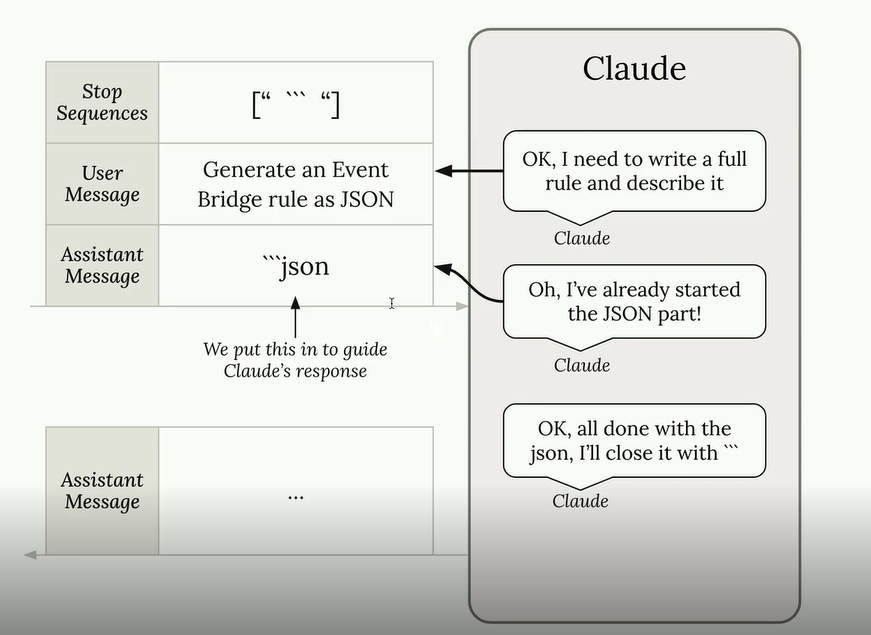

In [140]:
# Para capturar sólo el json (lo que va entre medias de ```json y ```). It is a powerful technique to get only the data that we want
messages = []
add_user_message(messages,"Generate a very short event bridge rule as json")
add_assistant_message(messages,"```json") # Para que el modelo vea que ya ha empezado con ```json
text = chat(messages,stop_sequences=["```"]) # Para que pare al final
print(text)

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1546086133.py:15: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar



{
  "Name": "OrderProcessingRule",
  "EventPattern": {
    "source": ["myapp.orders"],
    "detail-type": ["Order Placed"]
  },
  "Targets": [
    {
      "Id": "1",
      "Arn": "arn:aws:lambda:us-east-1:123456789012:function:ProcessOrder"
    }
  ]
}



In [139]:
import json

json.loads(text.strip())

{'Name': 'OrderProcessingRule',
 'EventPattern': {'source': ['myapp.orders'], 'detail-type': ['Order Placed']},
 'Targets': [{'Id': '1',
   'Arn': 'arn:aws:lambda:us-east-1:123456789012:function:ProcessOrder'}],
 'State': 'ENABLED'}

### Structured data exercise

* Use message prefilling and stop sequences only to get three different commands in a single response
* There shouldn't be any comments or explanation
* Hint: message prefilling isn't limited to just characters like ```

In [141]:
# Original
messages = []

prompt = """
Generate three different sample AWS CLI commands. Each should be very short.
"""

add_user_message(messages, prompt)

text = chat(messages)
text.strip()

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1546086133.py:15: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar


'Here are three short AWS CLI commands:\n\n1. **List S3 buckets:**\n   ```bash\n   aws s3 ls\n   ```\n\n2. **Describe EC2 instances:**\n   ```bash\n   aws ec2 describe-instances\n   ```\n\n3. **List IAM users:**\n   ```bash\n   aws iam list-users\n   ```'

In [150]:
messages = []

prompt = """
Generate three different sample AWS CLI commands. Each should be very short.
"""

add_user_message(messages, prompt)
# Message prefill (super importante)
add_assistant_message(messages, "Here are all three commands in a single block without any comments\n```bash") # It renders in Markdown (esto es importante)
# Chat with stop sequence
text = chat(messages,stop_sequences=["```"])
text.strip()

C:\Users\Andoni_Aguirre_Arang\AppData\Local\Temp\ipykernel_2404\1546086133.py:15: DeprecationWarning: The model 'claude-sonnet-4-0' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**params) # ⭐muy buena esta de usar **params para evitar un if y duplicar


'aws s3 ls s3://my-bucket\naws ec2 describe-instances --region us-east-1\naws iam list-users'

In [151]:
print(text.strip())

aws s3 ls s3://my-bucket
aws ec2 describe-instances --region us-east-1
aws iam list-users
